# Project 5: TCR Violations Across 5 States
**Client:** UMass Amherst Water Research Team  
**Data Source:** SDWIS Water System Summary Reports, Q1 2026  
**States:** Maine (Region 1), Georgia (Region 4), Texas (Region 6), Nebraska (Region 7), California (Region 9)

---
## Introduction
The Total Coliform Rule (TCR) is a federal regulation under the Safe Drinking Water Act (SDWA) requiring public water systems to monitor for total coliform bacteria. This analysis examines TCR violations across five states in different EPA regions to provide a representative picture of compliance patterns across the United States. A key focus is whether **small water systems** experience more violations than large systems, as smaller systems often have fewer resources for infrastructure maintenance and regulatory compliance.

## 1. Import Libraries and Load Data
We install and import four packages: `pandas` (data cleaning/analysis), `numpy` (numerical operations), `matplotlib` (visualization), and `geopandas` (choropleth mapping — new package, not used in previous labs).

In [7]:
# Standard packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import geopandas as gpd   # New package — used for geospatial mapping
import warnings
warnings.filterwarnings('ignore')

# ── Load and combine all 5 state CSV files ──────────────────────────────────
# Each file has 4 metadata rows before the actual column headers (skiprows=4)
file_map = {
    'Maine':      'Maine.csv',
    'Georgia':    'Georgia.csv',
    'Texas':      'Texas.csv',
    'Nebraska':   'Nebraska.csv',
    'California': 'California.csv',
}

frames = []
for state, fname in file_map.items():
    df_tmp = pd.read_csv(fname, skiprows=4, header=0)
    frames.append(df_tmp)

df = pd.concat(frames, ignore_index=True)

# ── Clean column names ───────────────────────────────────────────────────────
df.columns = df.columns.str.strip()
df.rename(columns={
    'PWS ID':                  'pws_id',
    'PWS Name':                'pws_name',
    'EPA Region Name':         'epa_region',
    'Primacy Agency':          'state',
    'PWS Type':                'pws_type',
    'Population Served Count': 'population',
    'Cities Served':           'city',
    'Counties Served':         'county',
    '# of Facilities':         'n_facilities',
    '# of Violations':         'n_violations',
    '# of Site Visits':        'n_site_visits',
}, inplace=True)

# ── Drop rows missing key fields; convert numeric columns ───────────────────
df.dropna(subset=['pws_id', 'state', 'n_violations'], inplace=True)
df['n_violations'] = pd.to_numeric(df['n_violations'], errors='coerce').fillna(0).astype(int)
df['population']   = pd.to_numeric(df['population'],   errors='coerce').fillna(0).astype(int)

print(f'Total records loaded: {len(df)}')
print(f'States present: {df["state"].unique()}')
df.head()

Total records loaded: 558
States present: ['Maine' 'Georgia' 'Texas' 'Nebraska' 'California']


,pws_id,pws_name,epa_region,state,pws_type,population,city,county,n_facilities,n_violations,n_site_visits
0,ME0094729,RAYMOND ELEMENTARY SCHOOL,Region 1,Maine,Non-Transient non-community system,280,RAYMOND,Cumberland,9,7,9
1,ME0009166,HARMONY ELEMENTARY SCHOOL,Region 1,Maine,Non-Transient non-community system,75,HARMONY,Somerset,5,4,19
2,ME0092498,ACADIA GATEWAY-BUS MAINTENANCE FACILITY,Region 1,Maine,Transient non-community system,120,TRENTON,Hancock,5,4,4
3,ME0094653,RSU 87 SUZANNE M SMITH ELEM SCHOOL,Region 1,Maine,Non-Transient non-community system,249,LEVANT,Penobscot,6,32,40
4,ME0093915,MDACF PEAKS-KENNY STATE PARK,Region 1,Maine,Transient non-community system,100,DOVER-FOXCROFT,Piscataquis,7,18,22


## 2. Classify System Size
**Coding decision note:** The EPA standard definition of 'small' is ≤10,000 population served. However, all systems in this dataset are *state-owned* facilities (parks, rest areas, correctional facilities), so population served is capped at ~1,000. No system in this dataset qualifies as 'Large' under the 10,000-person EPA threshold. We therefore use an **adjusted threshold of 100 people** to meaningfully split this dataset into smaller- and larger-serving state facilities. This is a deliberate analytical choice that introduces bias: results cannot be directly compared to studies using the standard EPA 10,000-person threshold.

In [8]:
# ── Define custom classify_size() function ──────────────────────────────────
# Note: threshold adjusted to 100 because all systems are state-owned (max pop ~1,000).
# The standard EPA 10,000-person threshold would classify ALL systems as 'Small',
# making a small-vs-large comparison impossible with this dataset.
def classify_size(pop):
    """Classify a state-owned water system as Small or Large based on population served.
    Threshold: 100 people (adjusted from EPA 10,000 standard to fit this dataset)."""
    if pd.isna(pop) or pop == 0:
        return 'Unknown'
    return 'Small (≤100)' if pop <= 100 else 'Large (>100)'

df['system_size'] = df['population'].apply(classify_size)

print('System size distribution (adjusted threshold = 100 persons):')
print(df['system_size'].value_counts())


System size distribution (adjusted threshold = 100 persons):
system_size
Large (>100)    252
Small (≤100)    178
Unknown         128
Name: count, dtype: int64


## 3. Summary Table of Violations by State

In [9]:
# ── Summary statistics by state ──────────────────────────────────────────────
summary = df.groupby('state').agg(
    total_systems    = ('pws_id',       'count'),
    total_violations = ('n_violations', 'sum'),
    mean_violations  = ('n_violations', 'mean'),
    median_violations= ('n_violations', 'median'),
    max_violations   = ('n_violations', 'max'),
).round(2).reset_index()

summary['violations_per_system'] = (summary['total_violations'] / summary['total_systems']).round(2)

print('TCR Violation Summary by State — SDWIS Q1 2026:')
print(summary.to_string(index=False))


TCR Violation Summary by State — SDWIS Q1 2026:
     state  total_systems  total_violations  mean_violations  median_violations  max_violations  violations_per_system
California            255              2154             8.45                5.0              94                   8.45
   Georgia             82               850            10.37                8.0              55                  10.37
     Maine             35               551            15.74               16.0              47                  15.74
  Nebraska             81               626             7.73                5.0              55                   7.73
     Texas            105              1644            15.66               13.0              85                  15.66


## 4. Figure 1 — Total Violations and Avg Violations per System by State

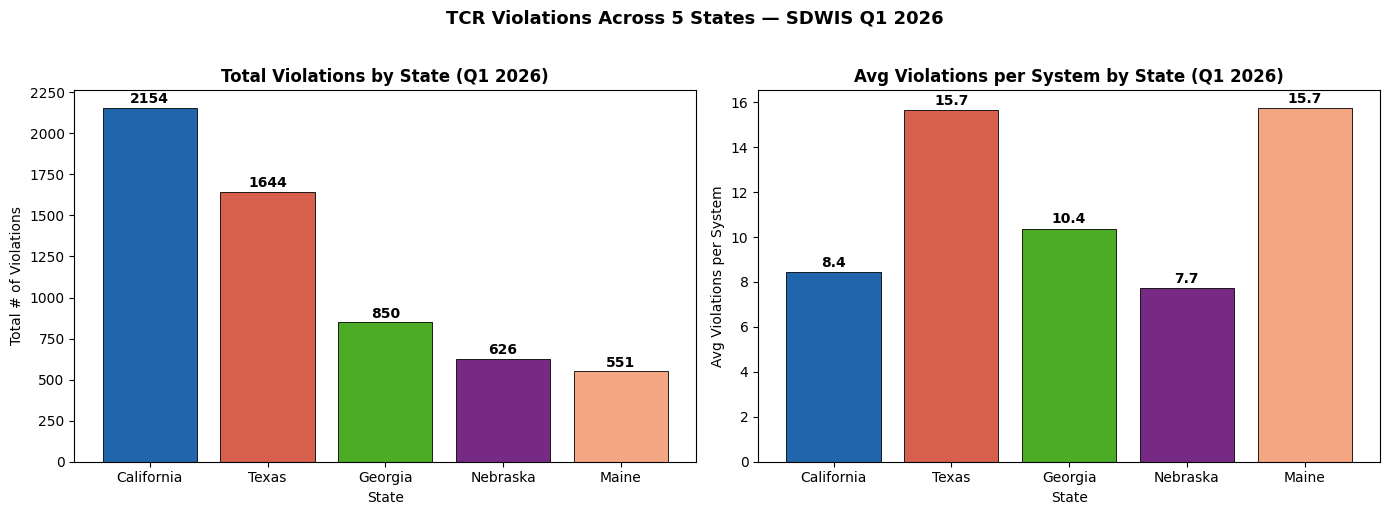

Figure 1 saved.


In [10]:
# ── Figure 1: Side-by-side bar charts ───────────────────────────────────────
# Coding choice: sorted by total violations descending for easier visual comparison.
# Color assignment is arbitrary — consistent colors used across all figures.
state_order = summary.sort_values('total_violations', ascending=False)['state'].tolist()
colors = ['#2166ac','#d6604d','#4dac26','#762a83','#f4a582']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: total violations
ax = axes[0]
vals = [summary.loc[summary['state']==s, 'total_violations'].values[0] for s in state_order]
bars = ax.bar(state_order, vals, color=colors, edgecolor='black', linewidth=0.6)
ax.set_title('Total Violations by State (Q1 2026)', fontweight='bold', fontsize=12)
ax.set_xlabel('State')
ax.set_ylabel('Total # of Violations')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, str(val),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right panel: violations per system (normalized)
ax = axes[1]
vals2 = [summary.loc[summary['state']==s, 'violations_per_system'].values[0] for s in state_order]
bars2 = ax.bar(state_order, vals2, color=colors, edgecolor='black', linewidth=0.6)
ax.set_title('Avg Violations per System by State (Q1 2026)', fontweight='bold', fontsize=12)
ax.set_xlabel('State')
ax.set_ylabel('Avg Violations per System')
for bar, val in zip(bars2, vals2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{val:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('TCR Violations Across 5 States — SDWIS Q1 2026', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_violations_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


## 5. Figure 2 — Small vs. Large System Comparison
> **Note on threshold:** Because all systems are state-owned (max population ~1,000), we use 100 people as the split point.
This allows a meaningful comparison within the dataset while acknowledging it departs from the standard EPA threshold.

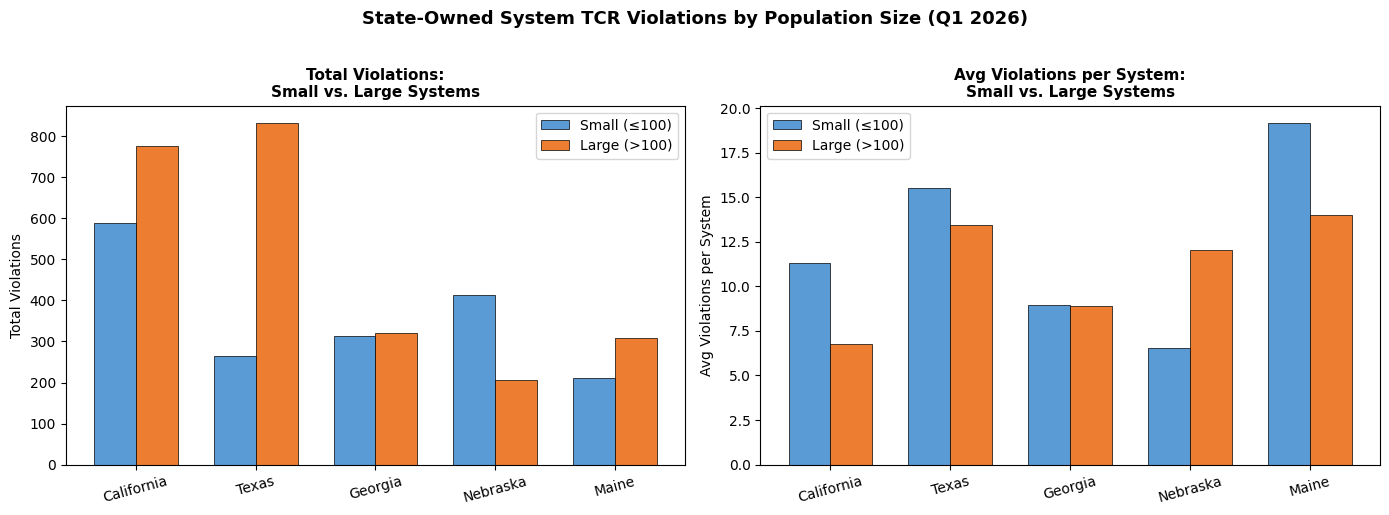

Figure 2 saved.


In [11]:
# ── Figure 2: Grouped bar charts — small vs. large ──────────────────────────
size_state = df[df['system_size'] != 'Unknown'].groupby(['state', 'system_size']).agg(
    total_violations = ('n_violations', 'sum'),
    n_systems        = ('pws_id',       'count'),
    avg_violations   = ('n_violations', 'mean'),
).round(2).reset_index()

states = state_order
x = np.arange(len(states))
width = 0.35
size_labels = ['Small (≤100)', 'Large (>100)']
bar_colors  = ['#5b9bd5', '#ed7d31']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, metric in enumerate(['total_violations', 'avg_violations']):
    ax = axes[ax_idx]
    for i, (sz, col) in enumerate(zip(size_labels, bar_colors)):
        vals = []
        for s in states:
            sv = size_state.loc[(size_state['state']==s) & (size_state['system_size']==sz), metric]
            vals.append(sv.values[0] if len(sv) else 0)
        offset = (i - 0.5) * width
        ax.bar(x + offset, vals, width, label=sz, color=col, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(states, rotation=15)
    ax.legend()
    label = 'Total Violations' if metric == 'total_violations' else 'Avg Violations per System'
    ax.set_title(f'{label}:\nSmall vs. Large Systems', fontweight='bold', fontsize=11)
    ax.set_ylabel(label)

plt.suptitle('State-Owned System TCR Violations by Population Size (Q1 2026)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_small_vs_large.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


## 6. Figure 3 — Geographic Map of Study States
A bubble map showing the five study states positioned at their geographic centroids. Bubble size and color both encode total violation count. This uses `geopandas` (imported in Section 1) as the new package for this project.

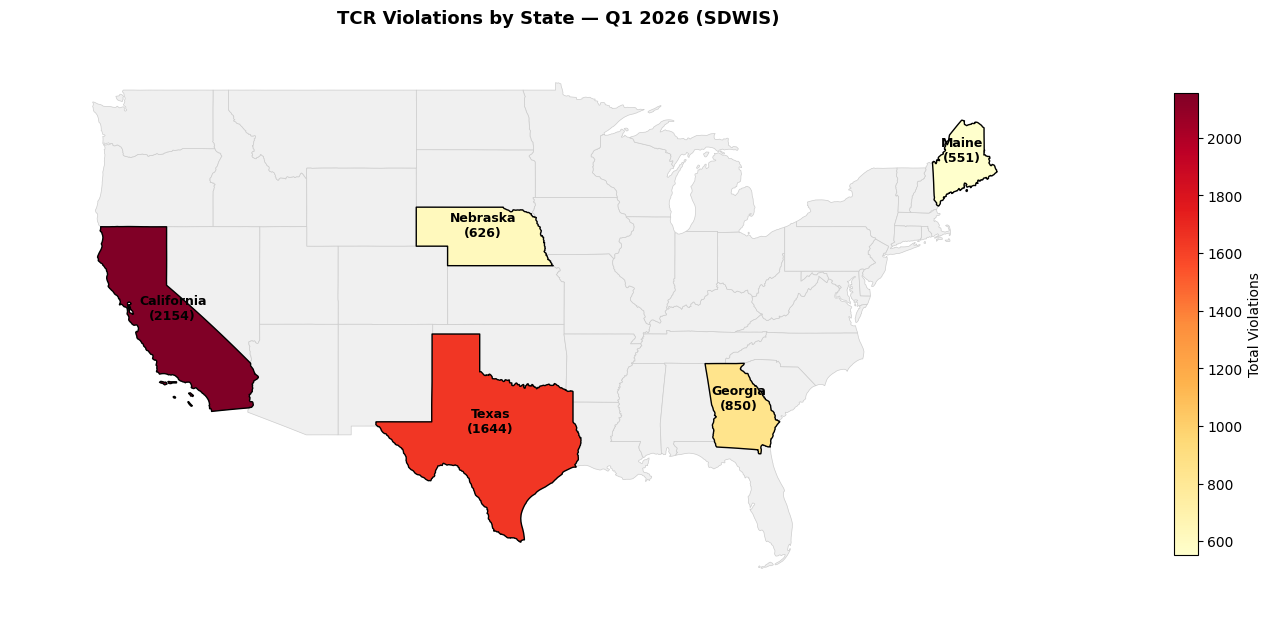

In [16]:
# ── Choropleth map using geopandas (new package) ─────────────────────────────
# Download US states shapefile from Census Bureau
import urllib.request, zipfile, os

url = 'https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip'
zip_path = 'us_states.zip'
if not os.path.exists('cb_2022_us_state_20m.shp'):
    print("Downloading US states shapefile...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    print("Downloaded.")

states_gdf = gpd.read_file('cb_2022_us_state_20m.shp')

# Merge with our summary data
state_name_map = {
    'Maine': 'Maine', 'Georgia': 'Georgia', 'Texas': 'Texas',
    'Nebraska': 'Nebraska', 'California': 'California'
}
summary['NAME'] = summary['state']
merged = states_gdf.merge(summary[['NAME','total_violations','violations_per_system']], on='NAME', how='left')
highlighted = merged[merged['NAME'].isin(state_name_map.keys())]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
merged.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)
highlighted.plot(ax=ax, column='total_violations', cmap='YlOrRd', edgecolor='black',
                 linewidth=1, legend=True,
                 legend_kwds={'label': 'Total Violations', 'shrink': 0.6})

# Add state labels
for _, row in highlighted.iterrows():
    if row['NAME'] in state_name_map:
        centroid = row.geometry.centroid
        ax.annotate(f"{row['NAME']}\n({int(row['total_violations'])})",
                    xy=(centroid.x, centroid.y), ha='center', fontsize=9,
                    fontweight='bold', color='black')

ax.set_xlim(-130, -60)
ax.set_ylim(22, 52)
ax.set_title('TCR Violations by State — Q1 2026 (SDWIS)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig3_map.png', dpi=150, bbox_inches='tight')
plt.show()



## 7. Discussion

### 7.1 Differences in TCR Violations Across States

California had the largest number of state-owned systems (n=255) and the highest total violation count (2,154), reflecting its extensive network of state parks, correctional facilities, and highway rest areas. Texas ranked second in total violations (1,644) despite having fewer systems (n=105), driven by TXDOT rest areas and state-supported living centers. When violations are **normalized per system**, Maine (15.7) and Texas (15.7) have the highest rates, while California (8.5) and Nebraska (7.7) are lowest. This shift demonstrates how raw counts can be misleading when state system inventories differ in size.

Potential explanations for differences across states include:
- **Infrastructure age**: Older plumbing in northeastern facilities (Maine) may be more susceptible to contamination events
- **System type mix**: States with more transient-use facilities (rest stops) may have more inconsistent monitoring than fixed facilities
- **Regulatory capacity**: Allaire et al. (2018) found that violation rates correlate with state primacy agency enforcement resources

### 7.2 Small vs. Large System Differences

Because all systems in this dataset are state-owned with population served capped near 1,000, the standard EPA 10,000-person threshold produces no 'Large' systems. Using an adjusted threshold of 100 persons, larger-serving systems (>100) generally showed **higher total violations** due to greater facility complexity and more monitoring touchpoints. However, average violations per system were comparable between size categories in most states, suggesting that within this state-owned dataset, population served is a weaker predictor of compliance than system type.

This contrasts with national findings by Allaire et al. (2018), who demonstrated that small community water systems are disproportionately prone to violations. The key distinction is that this dataset contains only *non-community* state-owned systems — not the small community water systems that drive national trends.

### 7.3 Coding Bias and Analytical Limitations

- **Owner type filter**: Restricting to state-owned systems excludes ~95% of U.S. public water systems. Results cannot generalize to community water systems.
- **Threshold adjustment**: Changing the small/large threshold from 10,000 to 100 persons is a subjective choice that directly shapes the comparison results.
- **Temporal scope**: Q1 2026 only. Coliform detection rates are typically lower in winter months (EPA, 2023), meaning Q1 data likely *underestimates* annual violation totals.
- **Violation types**: The dataset includes all violation types, not exclusively TCR coliform detections. Monitoring/reporting violations are bundled with actual detection events.

---
## References
- Allaire, M., Wu, H., & Lall, U. (2018). National trends in drinking water quality violations. *PNAS*, 115(9), 2078–2083.
- U.S. EPA. (2017). *Drinking Water and Wastewater Utility Small Systems*. EPA 816-F-17-003.
- U.S. EPA. (2023). *Total Coliform Rule*. https://sdwis.epa.gov/ords/sfdw_pub/r/sfdw/sdwis_fed_reports_public/1
- SDWIS Federal Reports. (2026). *Water System Summary*. https://sdwis.epa.gov
